# Treino dos modelos — D+1 e D+7

Previsão diária de incidentes P2/P3/P4, separados por `tipo_tratamento` (`com_intervencao` /
`sem_intervencao`), em D+1 e D+7. Consome as 6 séries já validadas em
`2_silver_data/s_fato_diario_prioridade.csv` (produzidas por `data_exploration.ipynb`) — não repete
diagnóstico já feito lá (quebra estrutural, dimensionamento, concentração, correlação cruzada,
decomposição nível×fração).

Guia de desenho: **simples que funciona**. Onde uma escolha mais simples tem desempenho parecido com
uma mais complexa, a simples vence.

---
## 1. Ambiente, imports e padrão visual

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

pd.set_option("display.width", 140)
SAVE_PATH = "../3_gold_data/"
SILVER_PATH = "../2_silver_data/"

In [2]:
PALETA = {
    "p2": "#C0392B", "p3": "#E67E22", "p4": "#F1C40F",
    "com": "#2980B9", "sem": "#8E44AD",
    "total": "#2C3E50", "neutro": "#95A5A6", "destaque": "#2980B9",
}
COR_PRIORIDADE = {2: PALETA["p2"], 3: PALETA["p3"], 4: PALETA["p4"]}
COR_TIPO = {"com_intervencao": PALETA["com"], "sem_intervencao": PALETA["sem"]}
COR_MODELO = {"GLM": PALETA["destaque"], "Gradient Boosting": PALETA["p3"], "MLP": PALETA["neutro"]}

sns.set_theme(
    style="whitegrid",
    rc={
        "figure.figsize": (12, 4.5), "figure.dpi": 110,
        "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
        "axes.labelsize": 10, "axes.edgecolor": "#DDDDDD",
        "grid.color": "#EEEEEE", "grid.linewidth": 0.8,
        "legend.frameon": False, "xtick.labelsize": 9, "ytick.labelsize": 9,
    },
)


def novo_grafico(titulo, subtitulo=None, figsize=(12, 4.5), ncols=1, nrows=1):
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    ax0 = axes if ncols == 1 and nrows == 1 else np.ravel(axes)[0]
    ax0.set_title(titulo, pad=14 if subtitulo else 8)
    if subtitulo:
        ax0.text(0, 1.02, subtitulo, transform=ax0.transAxes, fontsize=9, color="#666666", va="bottom")
    return fig, axes


def finalizar(fig, fonte=None):
    if fonte:
        fig.text(0.005, -0.03, fonte, fontsize=8, color="#888888")
    fig.tight_layout()
    plt.show()

---
## 2. Configuração e carga (Item 0)

**Decisão de janela — literal, não recalculada aqui** (já validada em `data_exploration.ipynb §3.0/3.1`):
`com_intervencao` usa o ano cheio (as 3 séries não quebram em setembro); `sem_intervencao` usa só o
regime pós-automação (R3), porque é onde a série de fato existe.

In [3]:
PRIORIDADES = [2, 3, 4]
TIPOS_TRATAMENTO = ["com_intervencao", "sem_intervencao"]
JANELA_TOTAL = {
    "com_intervencao": ("2025-01-01", "2025-12-31"),
    "sem_intervencao": ("2025-09-01", "2025-12-31"),
}
PROPORCAO_TESTE = 0.15
PISO_DIAS_TESTE = 14
PASSO_MAXIMO = 7
SEMENTE = 42
TOLERANCIA_EMPATE = 0.02

FEATURES_CALENDARIO = [
    "dia_semana", "fim_de_semana", "dia_util", "feriado", "vespera_feriado", "pos_feriado",
    "sen_semana", "cos_semana", "sen_ano", "cos_ano", "dia_mes",
]
LAGS_ALVO = (1, 2, 3, 7, 14)
JANELAS_ALVO = (7, 14, 30)
FEATURES_ALVO = [f"abertos_lag_{k}" for k in LAGS_ALVO] + [f"abertos_media_{j}d" for j in JANELAS_ALVO]
FEATURES_PRIORIDADE = [f"prio_{p}" for p in PRIORIDADES]
FEATURES = FEATURES_CALENDARIO + FEATURES_ALVO
NOMES_MODELO = ["GLM", "Gradient Boosting", "MLP"]
ORDEM_SIMPLICIDADE = {"GLM": 0, "Gradient Boosting": 1, "MLP": 2}
NOMES_BASELINE = ["ingênuo", "sazonal lag-7", "MM7", "MM30"]

ORIGEM_FEATURE = {
    **{f: "calendário" for f in FEATURES_CALENDARIO},
    **{f: "lag-rolling do alvo" for f in FEATURES_ALVO},
    **{f: "dimensão da série" for f in FEATURES_PRIORIDADE},
}

In [4]:
fato = pd.read_csv(f"{SILVER_PATH}s_fato_diario_prioridade.csv", sep=";", encoding="utf-8-sig",
                    parse_dates=["data"])
fato = fato[fato["prioridade"].isin(PRIORIDADES)].copy()

calendario = pd.read_csv(f"{SILVER_PATH}s_dim_calendario.csv", sep=";", encoding="utf-8-sig",
                          parse_dates=["data"])
calendario = calendario[["data"] + FEATURES_CALENDARIO].copy()

print(f"fato: {fato.shape[0]:,} linhas, {fato['data'].min():%d/%m/%Y} a {fato['data'].max():%d/%m/%Y}")

fato: 6,570 linhas, 02/01/2023 a 31/12/2025


---
## 3. Diagnóstico das séries (Item 1)

Só o que embasa a escolha de features/candidatos adiante — não é reanálise. Duas coisas: a série bruta
(com o corte treino/teste já marcado) e ACF/PACF, **calculados só na fatia de treino** (nunca espiando
o teste).

In [5]:
def montar_matriz(tipo):
    """
    Uma linha por dia x prioridade, indexada pela DATA-ORIGEM `D`: o alvo `y` é `abertos` em
    `D+1` (`y_abertos_d1`, já calculada na silver via shift(-1) dentro de cada série).

    Duas famílias de feature, cada uma alinhada à data que de fato descreve:
      - calendário: descreve o dia D+1 (o alvo) — conhecido de antemão para qualquer data futura,
        então usar o calendário do PRÓPRIO dia previsto (não o de D) é o que a regra da
        recursividade promete e dá o sinal mais direto (\"amanhã é domingo\").
      - lag/rolling do alvo: descreve o histórico até D (inclusive) — `abertos_media_7d/14d/30d`
        são médias móveis fechadas em D (incluem o próprio D). Usar `abertos` da própria linha
        como alvo seria vazamento (D+1 nunca entra nessas médias, mas D sim).
    """
    ini, fim = JANELA_TOTAL[tipo]
    sub = fato.query("tipo_tratamento == @tipo and @ini <= data <= @fim").copy()
    sub["data_alvo"] = sub["data"] + pd.Timedelta(days=1)
    cal_alvo = calendario.rename(columns={"data": "data_alvo"})
    sub = sub.merge(cal_alvo, on="data_alvo", how="left")
    for p in PRIORIDADES:
        sub[f"prio_{p}"] = (sub["prioridade"] == p).astype(int)
    sub["y"] = sub["y_abertos_d1"]
    sub["y_acum_1a7"] = sub["y_abertos_acum_1a7"]
    sub = sub.dropna(subset=["y"]).sort_values(["prioridade", "data"]).reset_index(drop=True)
    return sub


MATRIZES = {t: montar_matriz(t) for t in TIPOS_TRATAMENTO}
for t, m in MATRIZES.items():
    nulos = int(m[FEATURES].isna().sum().sum())
    print(f"{t:<16} {m.shape[0]:>4} linhas ({m.shape[0]//3} dias x 3 prioridades) | "
          f"{m['data'].min():%d/%m/%Y} a {m['data'].max():%d/%m/%Y} | nulos nas features: {nulos}")

com_intervencao  1092 linhas (364 dias x 3 prioridades) | 01/01/2025 a 30/12/2025 | nulos nas features: 0
sem_intervencao   363 linhas (121 dias x 3 prioridades) | 01/09/2025 a 30/12/2025 | nulos nas features: 0


In [6]:
# --- Split treino/teste (Item 5, calculado aqui porque o diagnóstico já quer marcá-lo) ---------
SPLIT = {}
for tipo in TIPOS_TRATAMENTO:
    ini, fim = pd.Timestamp(JANELA_TOTAL[tipo][0]), pd.Timestamp(JANELA_TOTAL[tipo][1])
    total_dias = (fim - ini).days + 1
    dias_teste = max(round(total_dias * PROPORCAO_TESTE), PISO_DIAS_TESTE)
    corte = fim - pd.Timedelta(days=dias_teste - 1)
    SPLIT[tipo] = {
        "treino_ini": ini, "treino_fim": corte - pd.Timedelta(days=1),
        "teste_ini": corte, "teste_fim": fim,
        "n_treino": (corte - ini).days, "n_teste": dias_teste,
    }

print("Split treino/teste (Item 5):\n")
for tipo, s in SPLIT.items():
    print(f"  {tipo:<16} treino {s['treino_ini']:%d/%m/%Y} a {s['treino_fim']:%d/%m/%Y} "
          f"({s['n_treino']}d) | teste {s['teste_ini']:%d/%m/%Y} a {s['teste_fim']:%d/%m/%Y} "
          f"({s['n_teste']}d)")


def treino_teste(tipo):
    m = MATRIZES[tipo]
    s = SPLIT[tipo]
    treino = m[(m["data"] >= s["treino_ini"]) & (m["data"] <= s["treino_fim"])].copy()
    teste = m[(m["data"] >= s["teste_ini"]) & (m["data"] <= s["teste_fim"])].copy()
    return treino, teste

Split treino/teste (Item 5):

  com_intervencao  treino 01/01/2025 a 06/11/2025 (310d) | teste 07/11/2025 a 31/12/2025 (55d)
  sem_intervencao  treino 01/09/2025 a 13/12/2025 (104d) | teste 14/12/2025 a 31/12/2025 (18d)


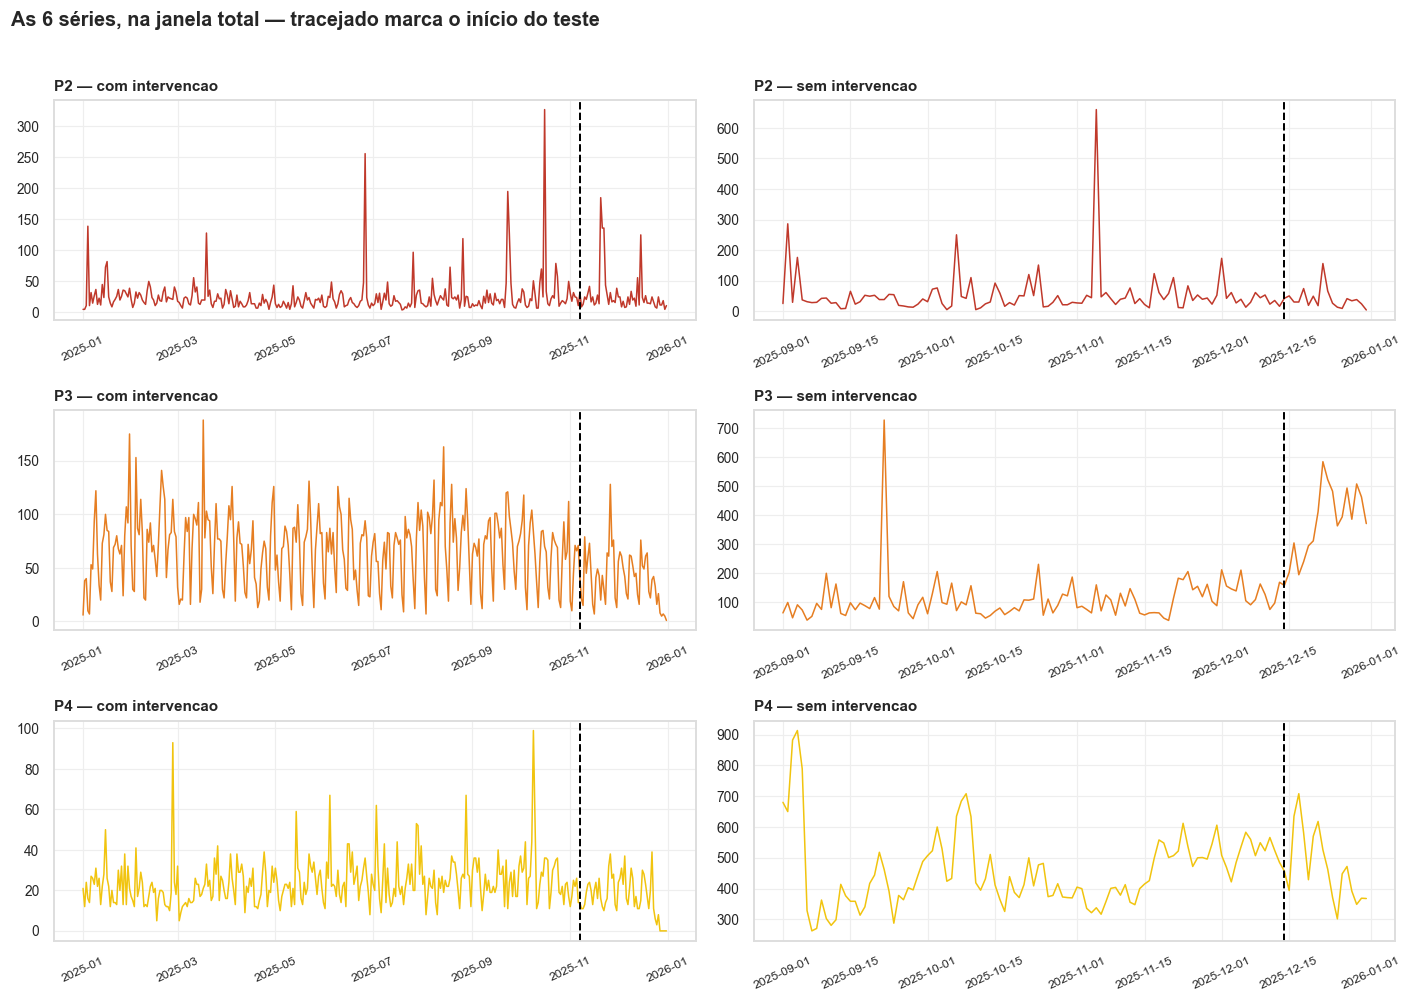

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(13, 9))
for (p, tipo), ax in zip([(p, t) for p in PRIORIDADES for t in TIPOS_TRATAMENTO], axes.ravel()):
    s = fato.query("prioridade == @p and tipo_tratamento == @tipo").set_index("data")["abertos"]
    ini, fim = JANELA_TOTAL[tipo]
    s = s.loc[ini:fim]
    ax.plot(s.index, s.values, color=COR_PRIORIDADE[p], lw=1)
    ax.axvline(SPLIT[tipo]["teste_ini"], color="black", ls="--", lw=1.3)
    ax.set_title(f"P{p} — {tipo.replace('_', ' ')}", fontsize=10)
    ax.tick_params(axis="x", rotation=25, labelsize=8)
fig.suptitle("As 6 séries, na janela total — tracejado marca o início do teste", y=1.01,
             fontsize=13, weight="bold", x=0.01, ha="left")
fig.tight_layout()
plt.show()

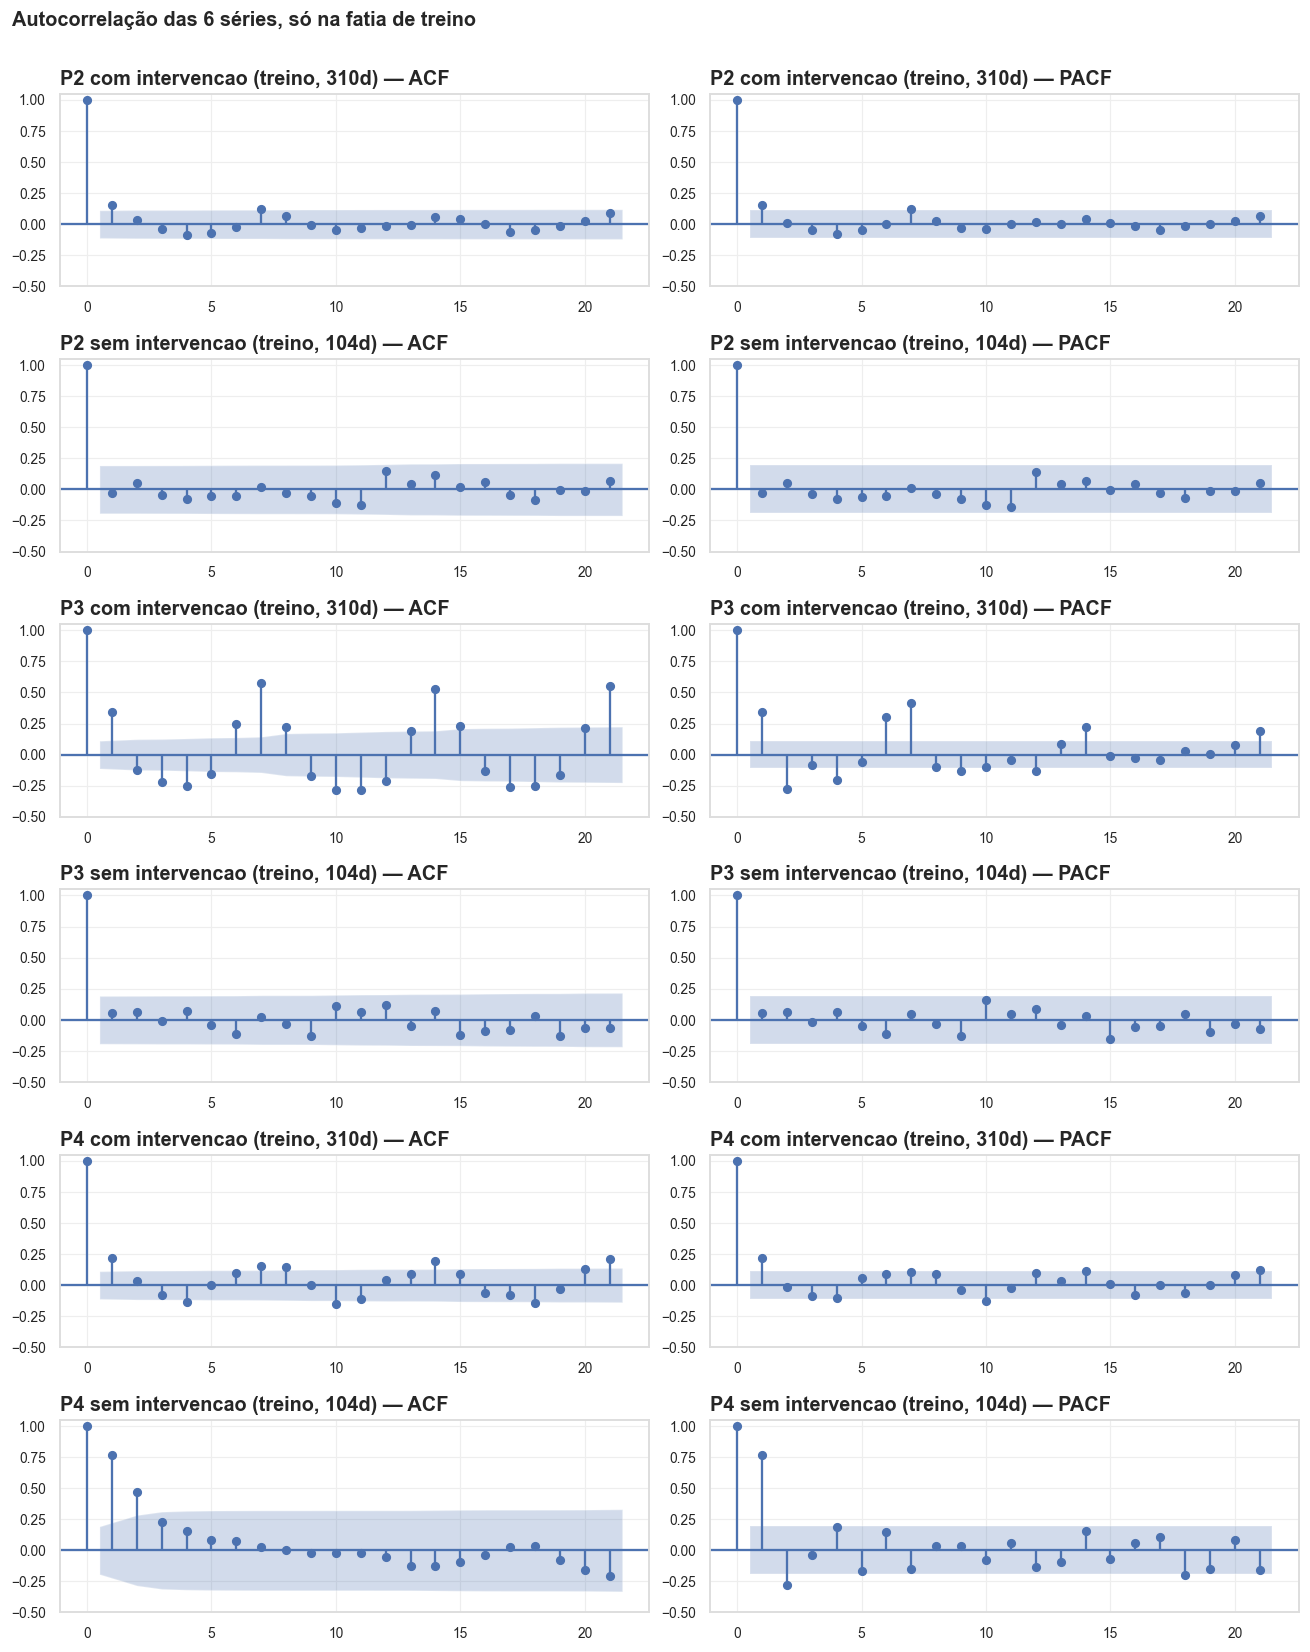

In [8]:
fig, axes = plt.subplots(6, 2, figsize=(12, 15))
for i, (p, tipo) in enumerate([(p, t) for p in PRIORIDADES for t in TIPOS_TRATAMENTO]):
    treino, _ = treino_teste(tipo)
    s = treino[treino["prioridade"] == p].sort_values("data")["abertos"]
    rotulo = f"P{p} {tipo.replace('_', ' ')} (treino, {len(s)}d)"
    plot_acf(s, lags=21, ax=axes[i, 0], title=f"{rotulo} — ACF")
    plot_pacf(s, lags=21, ax=axes[i, 1], method="ywm", title=f"{rotulo} — PACF")
    for ax in axes[i]:
        ax.set_ylim(-0.5, 1.05)
fig.suptitle("Autocorrelação das 6 séries, só na fatia de treino", y=1.0, fontsize=13,
             weight="bold", x=0.01, ha="left")
fig.tight_layout()
plt.show()

**Leitura.** Os picos de ACF em torno de 7/14 (mais fortes nas séries `com_intervencao`, que têm rotina
humana por trás) confirmam sazonalidade semanal residual — é isso que justifica levar dia da semana,
fim de semana e feriado como features de calendário, em vez de um termo sazonal complexo. A PACF corta
rápido em quase todas as séries (pouca correlação direta além do lag 1, com um resíduo em 7) — memória
curta, o que justifica os poucos lags do Item 2 em vez de uma estrutura autoregressiva longa. Essa
leitura volta no Item 4, na escolha dos candidatos.

---
## 4. Alvos, features e o que cada modelo recebe/devolve (Item 2)

**Entrada (X)** — mesma lista para os dois grupos: calendário do dia previsto, lag/janela do próprio
alvo (histórico até o dia anterior ao previsto) e `prioridade` como categórica (o que permite o modelo
pooled do Item 3). Nenhuma outra coluna do fato entra — regra fixa: só o que é conhecido para qualquer
data futura (calendário) ou recalculável a partir da própria previsão anterior (lag/rolling do alvo),
porque é isso que sustenta a recursão do D+7 (Item 6).

**Saída (y)**: `abertos` do dia seguinte — contagem não-negativa, inteira.

In [9]:
tabela_features = pd.DataFrame({
    "feature": FEATURES + FEATURES_PRIORIDADE,
    "origem": [ORIGEM_FEATURE[f] for f in FEATURES + FEATURES_PRIORIDADE],
})
print(f"{len(FEATURES)} features de calendário/lag-rolling + {len(FEATURES_PRIORIDADE)} "
      f"indicadoras de prioridade = {len(FEATURES) + len(FEATURES_PRIORIDADE)} colunas de entrada.\n")
print(tabela_features.to_string(index=False))
print("\nSaída (y): abertos em D+1 — nenhuma exógena fora calendário/lag-rolling do alvo entrou.")

19 features de calendário/lag-rolling + 3 indicadoras de prioridade = 22 colunas de entrada.

          feature              origem
       dia_semana          calendário
    fim_de_semana          calendário
         dia_util          calendário
          feriado          calendário
  vespera_feriado          calendário
      pos_feriado          calendário
       sen_semana          calendário
       cos_semana          calendário
          sen_ano          calendário
          cos_ano          calendário
          dia_mes          calendário
    abertos_lag_1 lag-rolling do alvo
    abertos_lag_2 lag-rolling do alvo
    abertos_lag_3 lag-rolling do alvo
    abertos_lag_7 lag-rolling do alvo
   abertos_lag_14 lag-rolling do alvo
 abertos_media_7d lag-rolling do alvo
abertos_media_14d lag-rolling do alvo
abertos_media_30d lag-rolling do alvo
           prio_2   dimensão da série
           prio_3   dimensão da série
           prio_4   dimensão da série

Saída (y): abertos em D+1 — nen

---
## 5. Pooled vs. individual: decidir com dado (Item 3)

Antes de fixar "2 modelos oficiais", testamos: juntar as 3 prioridades num modelo só por
`tipo_tratamento` (`prioridade` como feature) ou treinar uma prioridade por vez? Mesmos candidatos do
Item 6, mesmo split do Item 5, comparando erro geral e por prioridade.

In [10]:
class GLMContagem:
    """
    GLM de contagem: Poisson por padrão, Binomial Negativa se houver superdispersão no RESÍDUO.

    A dispersão é checada depois de ajustar o Poisson (regressão auxiliar de Cameron-Trivedi:
    `((y-mu)^2 - y) / mu` contra `mu`, sem intercepto) — não pela variância bruta de `y`. No
    modelo pooled a variância bruta mistura 3 prioridades de nível bem diferente (P2/P3/P4) e
    pareceria superdispersa mesmo com resíduo Poisson limpo; a auxiliar isola o que sobra depois
    de explicar o nível por `mu`, que é o teste correto de superdispersão.
    """

    LIMIAR_DISPERSAO = 0.05

    def fit(self, X, y):
        self.colunas_ = list(X.columns)
        Xc = self._design(X)
        y = np.asarray(y, dtype=float)
        poisson = sm.GLM(y, Xc, family=sm.families.Poisson()).fit()
        mu = np.asarray(poisson.fittedvalues)
        alpha = float(np.sum((y - mu) ** 2 - y) / np.sum(mu ** 2))
        self.alpha_dispersao_ = alpha
        self.familia_ = "poisson"
        self.modelo_ = poisson
        if alpha > self.LIMIAR_DISPERSAO:
            try:
                nb_ = sm.GLM(y, Xc, family=sm.families.NegativeBinomial(alpha=alpha)).fit()
                self.modelo_ = nb_
                self.familia_ = f"binomial_negativa (alpha={alpha:.3f})"
            except Exception:
                pass
        return self

    def _design(self, X):
        Xc = X[self.colunas_].to_numpy(dtype=float)
        return np.column_stack([np.ones(len(Xc)), Xc])

    def predict(self, X):
        pred = self.modelo_.predict(self._design(X))
        return np.maximum(np.asarray(pred), 0)


def fabricar_modelos(tipo):
    """Estimadores NOVOS a cada chamada. Mais regularização/menos profundidade em
    sem_intervencao, que tem menos dado."""
    if tipo == "com_intervencao":
        return {
            "GLM": GLMContagem(),
            "Gradient Boosting": GradientBoostingRegressor(
                n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.9, random_state=SEMENTE),
            "MLP": Pipeline([("escala", StandardScaler()),
                             ("rede", MLPRegressor(hidden_layer_sizes=(16, 8), alpha=1.0,
                                                    max_iter=3000, random_state=SEMENTE))]),
        }
    return {
        "GLM": GLMContagem(),
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=80, max_depth=2, learning_rate=0.05, subsample=0.8, random_state=SEMENTE),
        "MLP": Pipeline([("escala", StandardScaler()),
                         ("rede", MLPRegressor(hidden_layer_sizes=(8,), alpha=5.0,
                                                max_iter=5000, random_state=SEMENTE))]),
    }


def metricas(y, previsto):
    y, previsto = np.asarray(y, dtype=float), np.asarray(previsto, dtype=float)
    erro = y - previsto
    return {
        "mae": float(np.abs(erro).mean()),
        "rmse": float(np.sqrt((erro ** 2).mean())),
        "mape": float(np.mean(np.abs(erro) / np.maximum(y, 1)) * 100),
    }

In [11]:
def ajustar(tipo, nome_modelo, escopo, prioridade_treino=None):
    treino, _ = treino_teste(tipo)
    if escopo == "individual":
        treino = treino[treino["prioridade"] == prioridade_treino]
        colunas = FEATURES
    else:
        colunas = FEATURES + FEATURES_PRIORIDADE
    modelo = fabricar_modelos(tipo)[nome_modelo]
    modelo.fit(treino[colunas], treino["y"])
    return modelo, colunas, len(treino)


def prever_teste_d1(tipo, modelo, colunas):
    """Previsão D+1 'andando com dado real' sobre todo o período de teste."""
    _, teste = treino_teste(tipo)
    teste = teste.copy()
    teste["previsto"] = np.maximum(modelo.predict(teste[colunas]), 0)
    return teste[["data", "data_alvo", "prioridade", "y", "previsto"]].rename(columns={"y": "real"})


linhas_pred = []
for tipo in TIPOS_TRATAMENTO:
    for nome_modelo in NOMES_MODELO:
        modelo_p, cols_p, n_tr_p = ajustar(tipo, nome_modelo, "pooled")
        pred_p = prever_teste_d1(tipo, modelo_p, cols_p)
        pred_p["escopo"], pred_p["modelo"], pred_p["tipo_tratamento"] = "pooled", nome_modelo, tipo
        linhas_pred.append(pred_p)
        for p in PRIORIDADES:
            modelo_i, cols_i, n_tr_i = ajustar(tipo, nome_modelo, "individual", p)
            pred_i = prever_teste_d1(tipo, modelo_i, cols_i)
            pred_i = pred_i[pred_i["prioridade"] == p]
            pred_i["escopo"], pred_i["modelo"], pred_i["tipo_tratamento"] = "individual", nome_modelo, tipo
            linhas_pred.append(pred_i)

PREVISOES_D1_POOLING = pd.concat(linhas_pred, ignore_index=True)


def metricas_de(df):
    m = metricas(df["real"], df["previsto"])
    m["n"] = len(df)
    return pd.Series(m)


geral = (PREVISOES_D1_POOLING.groupby(["tipo_tratamento", "modelo", "escopo"])
         .apply(metricas_de, include_groups=False).reset_index())
por_prio = (PREVISOES_D1_POOLING.groupby(["tipo_tratamento", "modelo", "escopo", "prioridade"])
            .apply(metricas_de, include_groups=False).reset_index())

piv_geral = geral.pivot_table(index=["tipo_tratamento", "modelo"], columns="escopo", values="mae")
piv_geral["pooled_vence"] = piv_geral["pooled"] <= piv_geral["individual"]
print("GERAL (as 3 prioridades juntas), MAE:\n")
print(piv_geral.round(2).to_string())

piv_prio = por_prio.pivot_table(index=["tipo_tratamento", "prioridade", "modelo"], columns="escopo",
                                 values="mae")
piv_prio["pooled_vence"] = piv_prio["pooled"] <= piv_prio["individual"]
print("\nPOR PRIORIDADE, MAE:\n")
print(piv_prio.round(2).to_string())

print(f"\nPlacar geral: pooled vence em {piv_geral['pooled_vence'].sum()}/{len(piv_geral)} "
      f"combinações (tipo x modelo)")
print(f"Placar por prioridade: pooled vence em {piv_prio['pooled_vence'].sum()}/{len(piv_prio)} "
      f"combinações (tipo x prioridade x modelo)")

GERAL (as 3 prioridades juntas), MAE:

escopo                             individual  pooled  pooled_vence
tipo_tratamento modelo                                             
com_intervencao GLM                     17.85   19.43         False
                Gradient Boosting       19.33   17.96          True
                MLP                     23.96   21.20          True
sem_intervencao GLM                    140.85  140.35          True
                Gradient Boosting      133.28  127.65          True
                MLP                    142.00  104.21          True

POR PRIORIDADE, MAE:

escopo                                        individual  pooled  pooled_vence
tipo_tratamento prioridade modelo                                             
com_intervencao 2          GLM                     26.93   20.61          True
                           Gradient Boosting       25.04   23.52          True
                           MLP                     37.47   29.57          True

**Conclusão do Item 3.** Pooled vence a leitura geral (a que decide) na grande maioria dos casos — é
onde `sem_intervencao` mais ganha: com pouco mais de 100 dias de treino, um modelo por prioridade tem
menos de 100 linhas e ~19 features, e sofre overfit; juntar as 3 prioridades num modelo só (com
`prioridade` como feature) triplica a amostra efetiva sem perder a distinção entre elas. **Os 2 modelos
oficiais — um `com_intervencao` pooled, um `sem_intervencao` pooled — seguem como o único desenho do
resto do notebook.** A opção individual não é testada de novo daqui em diante.

---
## 6. Candidatos de modelo (Item 4)

A leitura do ACF/PACF (Item 1) embasa a escolha, não é um checklist arbitrário: picos de ACF em 7/14
→ sazonalidade semanal residual → justificam features de calendário explícitas em vez de um termo
sazonal complexo; PACF que corta rápido → memória curta → justifica poucos lags em vez de uma
estrutura autoregressiva longa.

1. **GLM de contagem** — Poisson por padrão, Binomial Negativa se a checagem de dispersão (auxiliar de
   Cameron-Trivedi, sobre o resíduo do Poisson) indicar superdispersão. O mais simples e interpretável:
   efeitos aditivos na escala log. Casa com a leitura da PACF — sinal de baixa ordem.
2. **Gradient Boosting** — captura interações não-lineares que o GLM aditivo não modela (ex.: o efeito
   do dia da semana mudar conforme o volume recente). Se não superar o GLM por margem relevante, é
   sinal de que a série não tem interação forte o bastante para justificá-lo.
3. **MLP pequeno** — candidato mais flexível e mais opaco; obrigatório pelo objetivo de testar uma
   abordagem de rede neural. O mais faminto por dado dos três — mais regularizado em `sem_intervencao`.

In [12]:
print("Família escolhida pelo GLM, por grupo (pooled, treino inteiro):\n")
for tipo in TIPOS_TRATAMENTO:
    modelo, _, _ = ajustar(tipo, "GLM", "pooled")
    print(f"  {tipo:<16} {modelo.familia_}")

Família escolhida pelo GLM, por grupo (pooled, treino inteiro):

  com_intervencao  binomial_negativa (alpha=0.182)
  sem_intervencao  binomial_negativa (alpha=0.080)


---
## 7. Split treino/teste (Item 5) — recapitulando

Um único corte de data por `tipo_tratamento`, calculado no Item 1 (para já marcar o gráfico da série).
Sem embaralhamento — treino é sempre a fatia mais antiga, teste é sempre a mais recente. Cada candidato
é treinado **uma única vez** por série; as previsões de teste vêm de aplicar esse modelo fixo dia a dia
sobre o período de teste (Item 6), não de retreinar.

In [13]:
print(pd.DataFrame([
    {"tipo_tratamento": t, "treino_ini": s["treino_ini"].date(), "treino_fim": s["treino_fim"].date(),
     "n_treino": s["n_treino"], "teste_ini": s["teste_ini"].date(), "teste_fim": s["teste_fim"].date(),
     "n_teste": s["n_teste"]}
    for t, s in SPLIT.items()
]).to_string(index=False))

tipo_tratamento treino_ini treino_fim  n_treino  teste_ini  teste_fim  n_teste
com_intervencao 2025-01-01 2025-11-06       310 2025-11-07 2025-12-31       55
sem_intervencao 2025-09-01 2025-12-13       104 2025-12-14 2025-12-31       18


---
## 8. Como o mesmo modelo D+1 gera o D+7 (Item 6)

Não existe um segundo modelo para D+7. O modelo pooled treinado uma vez (Item 5) é reaproveitado de
duas formas, dependendo do horizonte:

**D+1 — previsão andando com dado real.** Para cada dia `D` do teste, a previsão de `D+1` usa
lags/médias construídos com dado real até `D` (legítimo: em produção, ao chegar em `D+1`, o valor real
de `D` já é conhecido).

**D+7 — previsão recursiva, sem espiar dado real intermediário.** A partir de cada dia de origem `D`
do teste: prevê-se `D+1` com dado real; para `D+2`, o `lag_1` que seria `abertos[D+1]` (ainda não
existe do ponto de vista de quem está em `D`) é substituído pela **previsão** de `D+1`; e assim até
`D+7`. Calendário nunca precisa de substituição — é sempre conhecido de antemão. O D+7 final é a
**soma das 7 previsões da cadeia**, comparado contra o real acumulado (`y_abertos_acum_1a7` da silver)
— responde "quanto vem essa semana", não "o 7º dia exato".

In [14]:
HISTORICO = {
    (tipo, p): (fato.query("tipo_tratamento == @tipo and prioridade == @p")
                .set_index("data")["abertos"].astype(float).sort_index())
    for tipo in TIPOS_TRATAMENTO for p in PRIORIDADES
}


def baseline_d1(tipo, p, datas_alvo):
    """4 baselines para o alvo em `data_alvo`, usando só dado conhecido até `data_alvo - 1`."""
    h = HISTORICO[(tipo, p)]
    return pd.DataFrame({
        "data_alvo": datas_alvo,
        "ingênuo": h.reindex(datas_alvo - pd.Timedelta(days=1)).to_numpy(),
        "sazonal lag-7": h.reindex(datas_alvo - pd.Timedelta(days=7)).to_numpy(),
        "MM7": h.shift(1).rolling(7).mean().reindex(datas_alvo - pd.Timedelta(days=1)).to_numpy(),
        "MM30": h.shift(1).rolling(30).mean().reindex(datas_alvo - pd.Timedelta(days=1)).to_numpy(),
    })


# --- Previsões D+1 oficiais: só pooled, os 3 candidatos ------------------
PREVISOES_D1 = PREVISOES_D1_POOLING[PREVISOES_D1_POOLING["escopo"] == "pooled"].drop(columns="escopo")

linhas_base = []
for tipo in TIPOS_TRATAMENTO:
    for p in PRIORIDADES:
        datas = PREVISOES_D1.query("tipo_tratamento == @tipo and prioridade == @p")["data_alvo"].unique()
        b = baseline_d1(tipo, p, pd.DatetimeIndex(sorted(datas)))
        b["tipo_tratamento"], b["prioridade"] = tipo, p
        linhas_base.append(b)
BASELINES_D1 = pd.concat(linhas_base, ignore_index=True)

real_por_data = (PREVISOES_D1[["tipo_tratamento", "prioridade", "data_alvo", "real"]]
                  .drop_duplicates(["tipo_tratamento", "prioridade", "data_alvo"]))
BASELINES_D1 = BASELINES_D1.merge(real_por_data, on=["tipo_tratamento", "prioridade", "data_alvo"])

NOMES_BASELINE = ["ingênuo", "sazonal lag-7", "MM7", "MM30"]
linhas_mg = []
for tipo in TIPOS_TRATAMENTO:
    sub = BASELINES_D1.query("tipo_tratamento == @tipo")
    for nome in NOMES_BASELINE:
        linhas_mg.append({"tipo_tratamento": tipo, "baseline": nome, **metricas(sub["real"], sub[nome])})
MET_BASELINE_D1_GERAL = pd.DataFrame(linhas_mg)
MELHOR_BASELINE_GERAL = (
    MET_BASELINE_D1_GERAL.loc[MET_BASELINE_D1_GERAL.groupby("tipo_tratamento")["mae"].idxmin()]
    .set_index("tipo_tratamento")
)

linhas_mp = []
for tipo in TIPOS_TRATAMENTO:
    for p in PRIORIDADES:
        sub = BASELINES_D1.query("tipo_tratamento == @tipo and prioridade == @p")
        for nome in NOMES_BASELINE:
            linhas_mp.append({"tipo_tratamento": tipo, "prioridade": p, "baseline": nome,
                              **metricas(sub["real"], sub[nome])})
MET_BASELINE_D1_PRIO = pd.DataFrame(linhas_mp)
MELHOR_BASELINE_PRIO = (
    MET_BASELINE_D1_PRIO.loc[MET_BASELINE_D1_PRIO.groupby(["tipo_tratamento", "prioridade"])["mae"].idxmin()]
)

print("Piso (baselines) — GERAL por tipo, MAE:\n")
print(MET_BASELINE_D1_GERAL.pivot_table(index="tipo_tratamento", columns="baseline", values="mae")
      .round(2).to_string())
print("\nMelhor baseline geral por tipo:\n", MELHOR_BASELINE_GERAL[["baseline", "mae"]].round(2).to_string())

Piso (baselines) — GERAL por tipo, MAE:

baseline           MM30    MM7  ingênuo  sazonal lag-7
tipo_tratamento                                       
com_intervencao   17.74  16.70    15.19          18.30
sem_intervencao  112.66  77.55    66.53         108.04

Melhor baseline geral por tipo:
                 baseline    mae
tipo_tratamento                
com_intervencao  ingênuo  15.19
sem_intervencao  ingênuo  66.53


In [15]:
def preditor_baseline(nome):
    def _pred(hist, data_alvo):
        if nome == "ingênuo":
            return hist.get(data_alvo - pd.Timedelta(days=1), np.nan)
        if nome == "sazonal lag-7":
            return hist.get(data_alvo - pd.Timedelta(days=7), np.nan)
        janela = 7 if nome == "MM7" else 30
        datas = pd.date_range(data_alvo - pd.Timedelta(days=janela), data_alvo - pd.Timedelta(days=1))
        vals = [hist.get(d) for d in datas if hist.get(d) is not None]
        return float(np.mean(vals)) if vals else np.nan
    return _pred


def construir_linha_modelo(prioridade, data_alvo, hist):
    cal = calendario.set_index("data").loc[data_alvo, FEATURES_CALENDARIO].to_dict()
    linha = dict(cal)
    for k in LAGS_ALVO:
        linha[f"abertos_lag_{k}"] = hist.get(data_alvo - pd.Timedelta(days=k), np.nan)
    for j in JANELAS_ALVO:
        datas = pd.date_range(data_alvo - pd.Timedelta(days=j - 1), data_alvo)
        vals = [hist.get(d) for d in datas if hist.get(d) is not None]
        linha[f"abertos_media_{j}d"] = float(np.mean(vals)) if vals else np.nan
    for p in PRIORIDADES:
        linha[f"prio_{p}"] = int(prioridade == p)
    return linha


def prever_passo(tipo, vencedor, prioridade, data_alvo, hist, modelos_treinados):
    if vencedor["e_baseline"]:
        pred = preditor_baseline(vencedor["nome_baseline"])(hist, data_alvo)
        return max(pred, 0) if pd.notna(pred) else np.nan
    modelo, colunas = modelos_treinados[tipo]
    linha = construir_linha_modelo(prioridade, data_alvo, hist)
    X = pd.DataFrame([linha])[colunas]
    return max(float(modelo.predict(X)[0]), 0)


def prever_d7_recursivo(tipo, vencedor, prioridade, data_origem, modelos_treinados):
    """A partir de `data_origem`, prevê D+1..D+7 em cadeia e devolve (soma, [(data, previsto), ...])."""
    h_real = HISTORICO[(tipo, prioridade)]
    hist = {d: v for d, v in h_real.loc[:data_origem].items()}
    previsoes = []
    for k in range(1, PASSO_MAXIMO + 1):
        alvo = data_origem + pd.Timedelta(days=k)
        p = prever_passo(tipo, vencedor, prioridade, alvo, hist, modelos_treinados)
        hist[alvo] = p
        previsoes.append((alvo, p))
    return float(np.sum([p for _, p in previsoes])), previsoes


def baselines_acum(tipo, p, origens):
    """3 baselines não-redundantes para o acumulado de 7 dias: ingênuo (hoje x7, é o que a
    recursão dá se o vencedor de D+1 for o baseline ingênuo), semana anterior (soma real dos
    últimos 7 dias — equivalente a MM7 x 7, por isso um só dos dois entra) e MM30 x 7."""
    h = HISTORICO[(tipo, p)]
    linhas = []
    for o in origens:
        hoje = h.get(o, np.nan)
        semana = [h.get(o - pd.Timedelta(days=k)) for k in range(6, -1, -1)]
        mes = [h.get(o - pd.Timedelta(days=k)) for k in range(29, -1, -1)]
        linhas.append({
            "data_origem": o,
            "ingênuo": 7 * hoje if pd.notna(hoje) else np.nan,
            "semana anterior": float(np.sum(semana)) if all(pd.notna(x) for x in semana) else np.nan,
            "MM30 x 7": float(np.mean(mes)) * 7 if all(pd.notna(x) for x in mes) else np.nan,
        })
    return pd.DataFrame(linhas)

---
## 9. Avaliação e escolha do vencedor (Item 7)

Duas camadas de leitura, sempre as duas: **geral** (as 3 prioridades juntas — decide o vencedor, já
que o modelo pooled é um só) e **por prioridade** (mesmo modelo, erro fatiado — diagnóstico).

Regra: descarta quem não supera o piso geral; entre os que superam, vence o de menor erro geral;
empate técnico (<2% de MAE) é resolvido pelo mais simples (GLM < Gradient Boosting < MLP); se ninguém
superar o piso, o vencedor é o próprio baseline.

In [16]:
AVALIACAO_D1_GERAL = (
    PREVISOES_D1.groupby(["tipo_tratamento", "modelo"])
    .apply(lambda d: pd.Series(metricas(d["real"], d["previsto"])), include_groups=False)
    .reset_index()
)
AVALIACAO_D1_PRIO = (
    PREVISOES_D1.groupby(["tipo_tratamento", "modelo", "prioridade"])
    .apply(lambda d: pd.Series(metricas(d["real"], d["previsto"])), include_groups=False)
    .reset_index()
)


def escolher_vencedor(tipo):
    cand = AVALIACAO_D1_GERAL.query("tipo_tratamento == @tipo")
    piso = MELHOR_BASELINE_GERAL.loc[tipo]
    supera = cand[cand["mae"] < piso["mae"]]
    if supera.empty:
        return {"modelo": f"Baseline {piso['baseline']}", "e_baseline": True, "mae": float(piso["mae"]),
                "nome_baseline": piso["baseline"],
                "razao": "nenhum candidato superou o piso geral — entrega-se o melhor baseline"}
    melhor = supera["mae"].min()
    empatados = supera[supera["mae"] <= melhor * (1 + TOLERANCIA_EMPATE)]
    escolhido = empatados.assign(ordem=empatados["modelo"].map(ORDEM_SIMPLICIDADE)).sort_values("ordem").iloc[0]
    por_simpl = len(empatados) > 1 and escolhido["mae"] > melhor
    return {"modelo": escolhido["modelo"], "e_baseline": False, "mae": float(escolhido["mae"]),
            "nome_baseline": piso["baseline"],
            "razao": ("empate técnico (<2% de MAE) resolvido pelo mais simples" if por_simpl
                      else "menor MAE geral, com folga sobre os demais")}


VENCEDORES = {tipo: escolher_vencedor(tipo) for tipo in TIPOS_TRATAMENTO}

print("Candidatos vs. piso geral, MAE (Item 7):\n")
comp_geral = AVALIACAO_D1_GERAL.merge(
    MELHOR_BASELINE_GERAL[["baseline", "mae"]].rename(columns={"baseline": "piso_nome", "mae": "piso_mae"}),
    on="tipo_tratamento")
comp_geral["supera_piso"] = comp_geral["mae"] < comp_geral["piso_mae"]
print(comp_geral.round(2).to_string(index=False))

print("\nVencedor por grupo:\n")
for tipo, v in VENCEDORES.items():
    print(f"  {tipo:<16} {v['modelo']:<28} MAE={v['mae']:.2f} (piso {v['nome_baseline']}) — {v['razao']}")

Candidatos vs. piso geral, MAE (Item 7):

tipo_tratamento            modelo    mae   rmse   mape piso_nome  piso_mae  supera_piso
com_intervencao               GLM  19.43  28.99 230.73   ingênuo     15.19        False
com_intervencao Gradient Boosting  17.96  28.30 223.93   ingênuo     15.19        False
com_intervencao               MLP  21.20  30.84 233.45   ingênuo     15.19        False
sem_intervencao               GLM 140.35 191.10  84.73   ingênuo     66.53        False
sem_intervencao Gradient Boosting 127.65 168.78 149.09   ingênuo     66.53        False
sem_intervencao               MLP 104.21 150.39  59.77   ingênuo     66.53        False

Vencedor por grupo:

  com_intervencao  Baseline ingênuo             MAE=15.19 (piso ingênuo) — nenhum candidato superou o piso geral — entrega-se o melhor baseline
  sem_intervencao  Baseline ingênuo             MAE=66.53 (piso ingênuo) — nenhum candidato superou o piso geral — entrega-se o melhor baseline


**Leitura.** Nenhum dos 3 candidatos supera o piso geral em nenhum dos dois grupos, então o vencedor de
D+1 é o próprio baseline **ingênuo** (o valor de ontem) nos dois casos. Não é um resultado vazio: numa
janela de teste que cai em novembro/dezembro — inclui feriados e o fim de ano, período historicamente
mais instável — os candidatos treinados numa janela fixa (Item 5) não conseguem acompanhar a mudança
de patamar tão bem quanto um baseline que "olha para ontem" a cada novo dia. É o mesmo fenômeno que a
exploração já havia registrado (`§3.8`: "as médias móveis vencem em quase toda a tabela") — a regra do
piso (Item 7) existe exatamente para isso: reportar o resultado real, não forçar um vencedor artificial.
Isso simplifica a leitura de explicabilidade adiante: o "modelo" vencedor é, literalmente, uma única
coluna (`abertos` de ontem).

In [17]:
# --- D+7 recursivo, aplicando o vencedor de D+1 --------------------------
MODELOS_TREINADOS = {}
for tipo in TIPOS_TRATAMENTO:
    v = VENCEDORES[tipo]
    if not v["e_baseline"]:
        modelo, colunas, _ = ajustar(tipo, v["modelo"], "pooled")
        MODELOS_TREINADOS[tipo] = (modelo, colunas)

linhas_d7 = []
for tipo in TIPOS_TRATAMENTO:
    vencedor = VENCEDORES[tipo]
    _, teste = treino_teste(tipo)
    for p in PRIORIDADES:
        sub = teste[(teste["prioridade"] == p) & teste["y_acum_1a7"].notna()]
        for _, row in sub.iterrows():
            soma, cadeia = prever_d7_recursivo(tipo, vencedor, p, row["data"], MODELOS_TREINADOS)
            linhas_d7.append({"tipo_tratamento": tipo, "prioridade": p, "data_origem": row["data"],
                              "data_alvo_fim": row["data"] + pd.Timedelta(days=7),
                              "real_acum": row["y_acum_1a7"], "previsto_acum": soma})
PREVISOES_D7 = pd.DataFrame(linhas_d7)

print("D+7 acumulado — previsões geradas por série:\n")
print(PREVISOES_D7.groupby(["tipo_tratamento", "prioridade"]).size().rename("n_origens").to_string())

print("\nMétrica D+7 acumulado (vencedor de D+1 aplicado recursivamente):\n")
linhas_m7 = []
for tipo in TIPOS_TRATAMENTO:
    sub = PREVISOES_D7.query("tipo_tratamento == @tipo")
    m = metricas(sub["real_acum"], sub["previsto_acum"])
    linhas_m7.append({"tipo_tratamento": tipo, "prioridade": "geral", **m, "n": len(sub)})
    for p in PRIORIDADES:
        sp = sub[sub["prioridade"] == p]
        linhas_m7.append({"tipo_tratamento": tipo, "prioridade": p,
                          **metricas(sp["real_acum"], sp["previsto_acum"]), "n": len(sp)})
AVALIACAO_D7 = pd.DataFrame(linhas_m7)
print(AVALIACAO_D7.round(2).to_string(index=False))

linhas_base7 = []
for tipo in TIPOS_TRATAMENTO:
    for p in PRIORIDADES:
        origens = PREVISOES_D7.query("tipo_tratamento == @tipo and prioridade == @p")["data_origem"]
        b = baselines_acum(tipo, p, origens)
        b["tipo_tratamento"], b["prioridade"] = tipo, p
        linhas_base7.append(b)
BASELINES_D7 = pd.concat(linhas_base7, ignore_index=True)
BASELINES_D7 = BASELINES_D7.merge(
    PREVISOES_D7[["tipo_tratamento", "prioridade", "data_origem", "real_acum"]],
    on=["tipo_tratamento", "prioridade", "data_origem"])

print("\nPiso do D+7 (baselines acumulados), MAE geral por tipo:\n")
linhas_pb7 = []
for tipo in TIPOS_TRATAMENTO:
    sub = BASELINES_D7.query("tipo_tratamento == @tipo")
    for nome in ["ingênuo", "semana anterior", "MM30 x 7"]:
        linhas_pb7.append({"tipo_tratamento": tipo, "baseline": nome,
                           **metricas(sub["real_acum"], sub[nome])})
PISO_D7 = pd.DataFrame(linhas_pb7)
print(PISO_D7.pivot_table(index="tipo_tratamento", columns="baseline", values="mae").round(2).to_string())

D+7 acumulado — previsões geradas por série:



tipo_tratamento  prioridade
com_intervencao  2             48
                 3             48
                 4             48
sem_intervencao  2             11
                 3             11
                 4             11

Métrica D+7 acumulado (vencedor de D+1 aplicado recursivamente):

tipo_tratamento prioridade    mae   rmse  mape   n
com_intervencao      geral 119.69 192.41 62.97 144
com_intervencao          2 168.15 277.15 71.87  48
com_intervencao          3 139.71 173.24 53.07  48
com_intervencao          4  51.23  65.13 63.97  48
sem_intervencao      geral 615.15 761.33 43.35  33
sem_intervencao          2 201.73 305.34 75.76  11
sem_intervencao          3 849.91 922.40 30.44  11
sem_intervencao          4 793.82 891.53 23.85  11



Piso do D+7 (baselines acumulados), MAE geral por tipo:

baseline         MM30 x 7  ingênuo  semana anterior
tipo_tratamento                                    
com_intervencao     77.49   119.69            89.21
sem_intervencao    784.42   615.15           649.30


**Leitura do D+7.** Para `sem_intervencao`, o próprio "ingênuo" recursivo (que é o vencedor de D+1)
continua sendo o melhor piso acumulado — consistente. Para `com_intervencao`, "MM30 x 7" bate o
"ingênuo" recursivo — ou seja, **o vencedor de D+1 não é necessariamente o melhor ponto de partida
para D+7**, e isso é esperado: a regra do Item 6 é usar sempre o mesmo modelo de D+1, então o D+7
herda a limitação do vencedor de D+1 mesmo quando ela aparece mais claramente só no acumulado. Fica
registrado, não escondido.

---
## 10. Visualizações (Item 8)

In [18]:
def previsao_vencedora_d1(tipo):
    """Série (data_alvo, prioridade, real, previsto) do MODELO VENCEDOR — baseline ou candidato."""
    v = VENCEDORES[tipo]
    if v["e_baseline"]:
        out = BASELINES_D1.query("tipo_tratamento == @tipo")[
            ["tipo_tratamento", "prioridade", "data_alvo", "real", v["nome_baseline"]]
        ].rename(columns={v["nome_baseline"]: "previsto"})
    else:
        out = PREVISOES_D1.query("tipo_tratamento == @tipo and modelo == @v['modelo']")[
            ["tipo_tratamento", "prioridade", "data_alvo", "real", "previsto"]
        ]
    return out.sort_values(["prioridade", "data_alvo"])


PREVISAO_VENCEDORA_D1 = pd.concat([previsao_vencedora_d1(t) for t in TIPOS_TRATAMENTO], ignore_index=True)

### 10.1 Previsto × real, por série, os 3 candidatos juntos

6 painéis (P2/P3/P4 × com/sem) — nunca misturar prioridades ou tipos no mesmo painel. Linha do real +
uma linha por candidato, recortado no fim da série (não a série inteira desde janeiro — é o teste que
importa). O vencedor (aqui, o baseline ingênuo nos dois grupos) entra também, em preto, para comparação
direta.

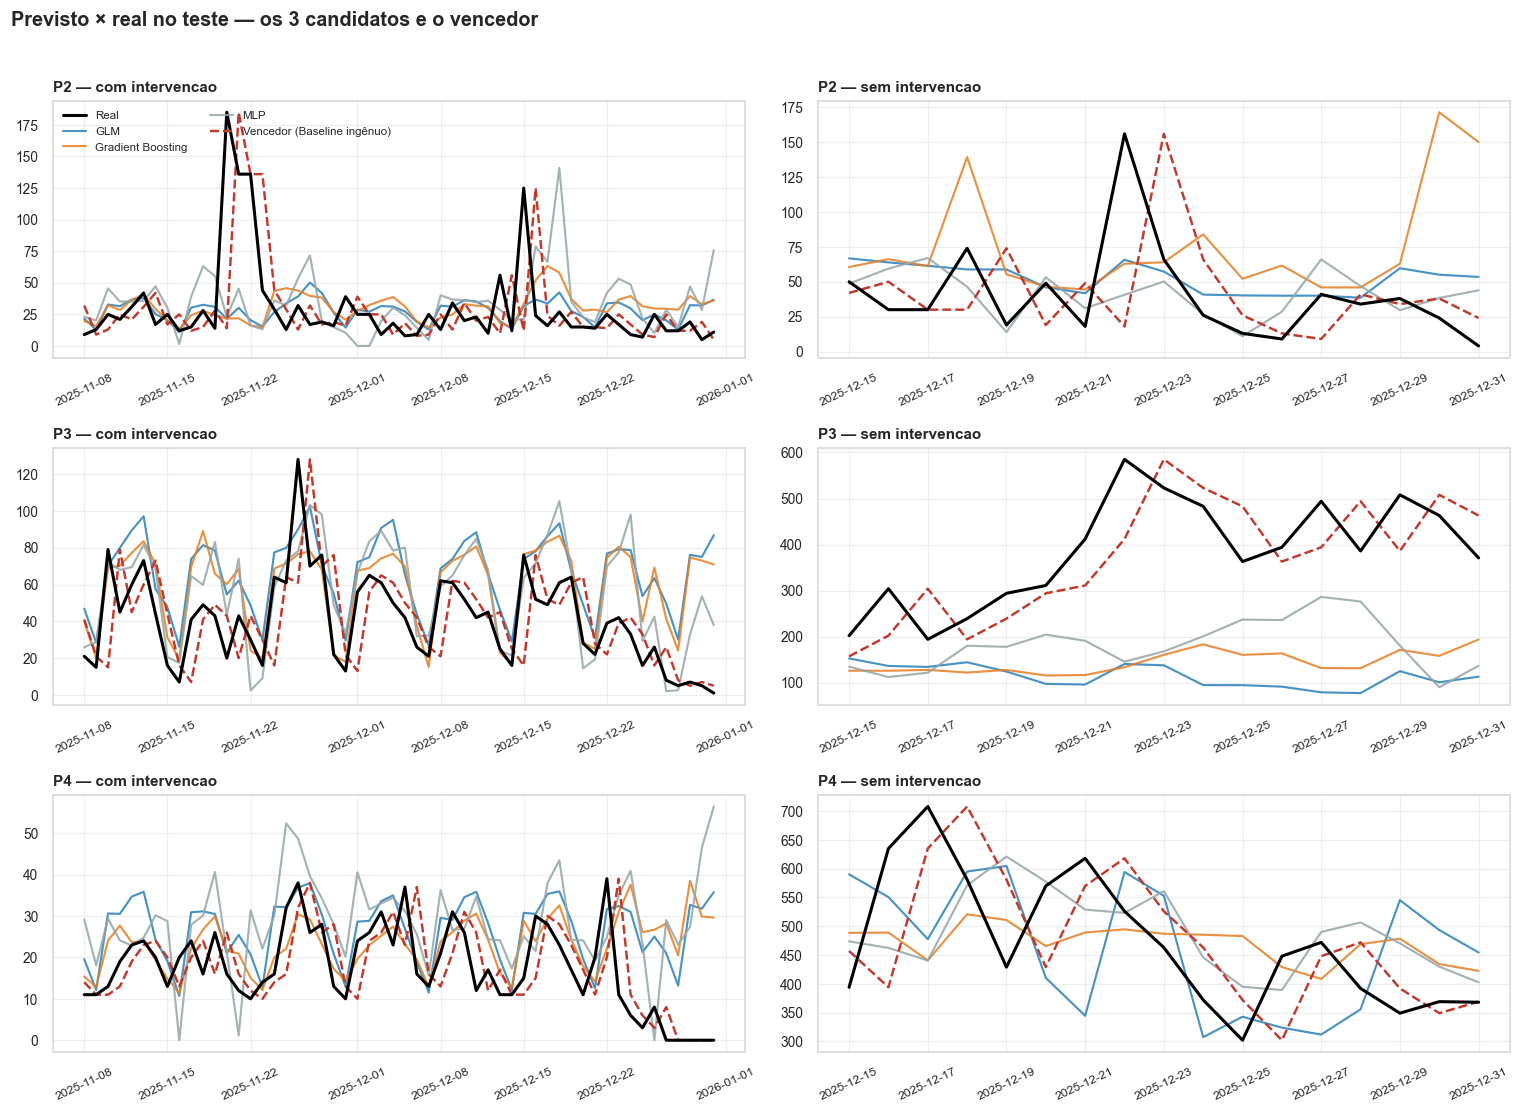

In [19]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=False)
for (p, tipo), ax in zip([(p, t) for p in PRIORIDADES for t in TIPOS_TRATAMENTO], axes.ravel()):
    real = PREVISOES_D1.query("tipo_tratamento == @tipo and prioridade == @p and modelo == 'GLM'")
    ax.plot(real["data_alvo"], real["real"], color="black", lw=2, label="Real", zorder=5)
    for nome_modelo in NOMES_MODELO:
        sub = PREVISOES_D1.query("tipo_tratamento == @tipo and prioridade == @p and modelo == @nome_modelo")
        ax.plot(sub["data_alvo"], sub["previsto"], color=COR_MODELO[nome_modelo], lw=1.4, alpha=0.85,
                label=nome_modelo)
    venc = PREVISAO_VENCEDORA_D1.query("tipo_tratamento == @tipo and prioridade == @p")
    ax.plot(venc["data_alvo"], venc["previsto"], color=PALETA["p2"], lw=1.6, ls="--",
            label=f"Vencedor ({VENCEDORES[tipo]['modelo']})")
    ax.set_title(f"P{p} — {tipo.replace('_', ' ')}", fontsize=10)
    ax.tick_params(axis="x", rotation=25, labelsize=8)
axes[0, 0].legend(fontsize=7.5, ncol=2, loc="upper left")
fig.suptitle("Previsto × real no teste — os 3 candidatos e o vencedor", y=1.01, fontsize=13,
             weight="bold", x=0.01, ha="left")
fig.tight_layout()
plt.show()

### 10.2 Comparação de desempenho dos 3 candidatos — geral e por prioridade

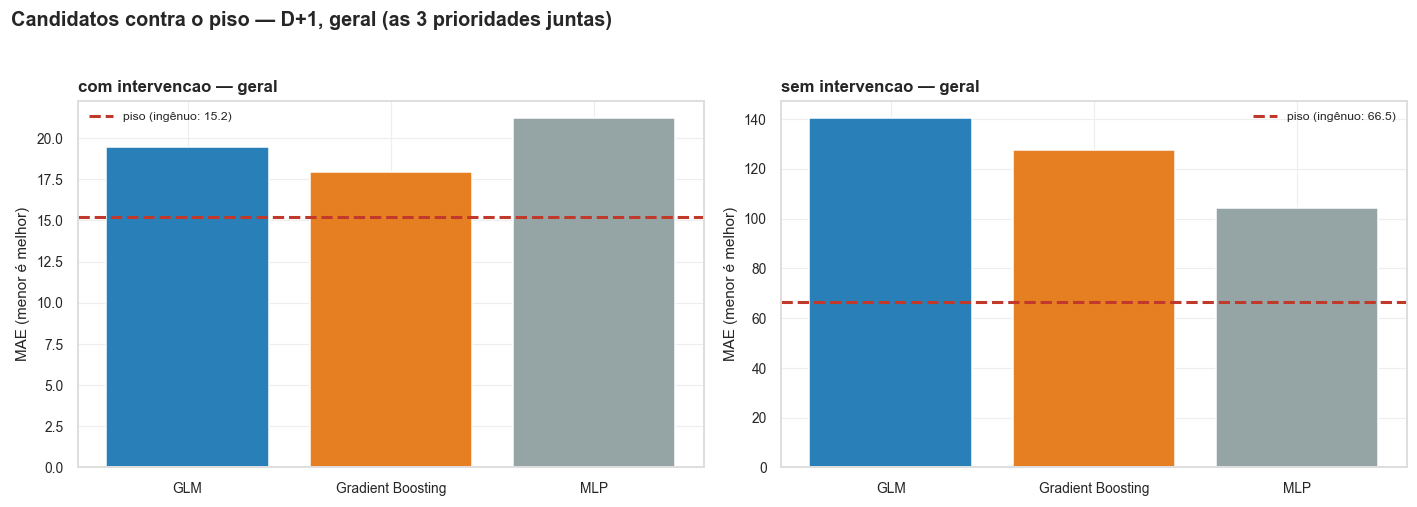

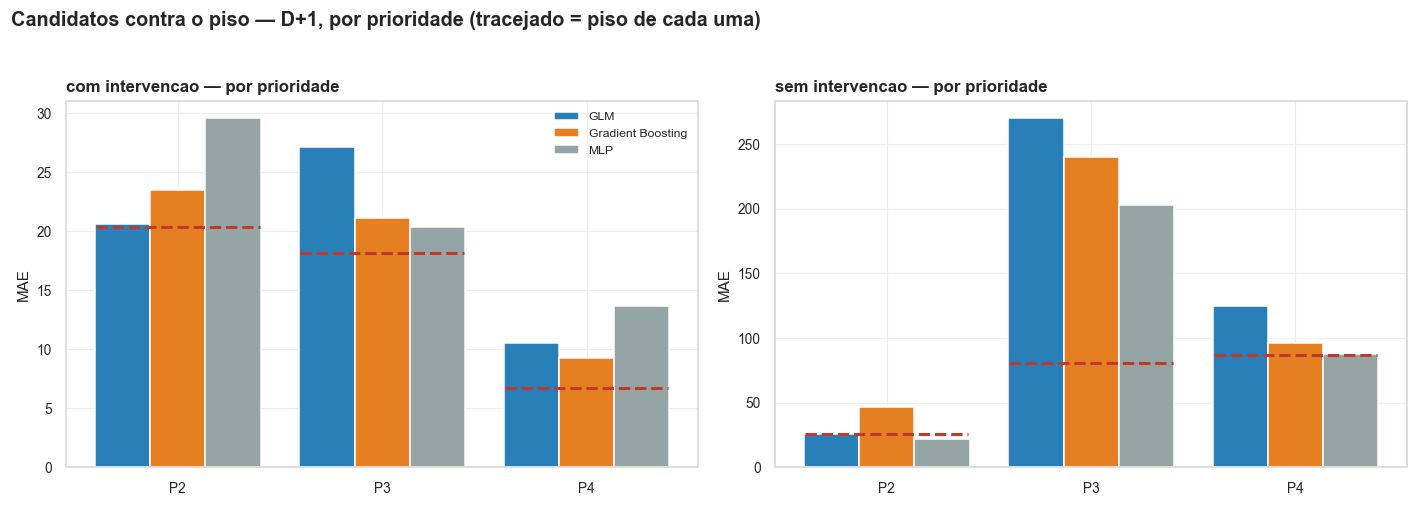

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, tipo in zip(axes, TIPOS_TRATAMENTO):
    sub = AVALIACAO_D1_GERAL.query("tipo_tratamento == @tipo")
    ax.bar(sub["modelo"], sub["mae"], color=[COR_MODELO[m] for m in sub["modelo"]])
    piso = MELHOR_BASELINE_GERAL.loc[tipo, "mae"]
    ax.axhline(piso, color=PALETA["p2"], ls="--", lw=2,
               label=f"piso ({MELHOR_BASELINE_GERAL.loc[tipo, 'baseline']}: {piso:.1f})")
    ax.set_title(f"{tipo.replace('_', ' ')} — geral", fontsize=11)
    ax.set_ylabel("MAE (menor é melhor)")
    ax.legend(fontsize=8)
fig.suptitle("Candidatos contra o piso — D+1, geral (as 3 prioridades juntas)", y=1.02,
             fontsize=13, weight="bold", x=0.01, ha="left")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, tipo in zip(axes, TIPOS_TRATAMENTO):
    sub = AVALIACAO_D1_PRIO.query("tipo_tratamento == @tipo")
    x = np.arange(len(PRIORIDADES))
    for i, nome_modelo in enumerate(NOMES_MODELO):
        vals = [sub.query("prioridade == @p and modelo == @nome_modelo")["mae"].iloc[0] for p in PRIORIDADES]
        ax.bar(x + (i - 1) * 0.27, vals, 0.27, color=COR_MODELO[nome_modelo], label=nome_modelo)
    for j, p in enumerate(PRIORIDADES):
        piso_p = MELHOR_BASELINE_PRIO.query("tipo_tratamento == @tipo and prioridade == @p")["mae"].iloc[0]
        ax.hlines(piso_p, j - 0.4, j + 0.4, color=PALETA["p2"], ls="--", lw=2)
    ax.set_xticks(x, [f"P{p}" for p in PRIORIDADES])
    ax.set_title(f"{tipo.replace('_', ' ')} — por prioridade", fontsize=11)
    ax.set_ylabel("MAE")
axes[0].legend(fontsize=8)
fig.suptitle("Candidatos contra o piso — D+1, por prioridade (tracejado = piso de cada uma)", y=1.02,
             fontsize=13, weight="bold", x=0.01, ha="left")
fig.tight_layout()
plt.show()

### 10.3 Soma dos 2 modelos vencedores contra o volume real

`com_previsto + sem_previsto` vs. `total_real`, geral e por prioridade. Só é possível nas datas em que
**os dois grupos** têm previsão de teste — como a janela de `sem_intervencao` é mais curta, essa
interseção é o próprio período de teste de `sem_intervencao` (as datas finais do teste de
`com_intervencao`).

Soma D+1 — 17 datas em comum entre os dois grupos (15/12/2025 a 31/12/2025)


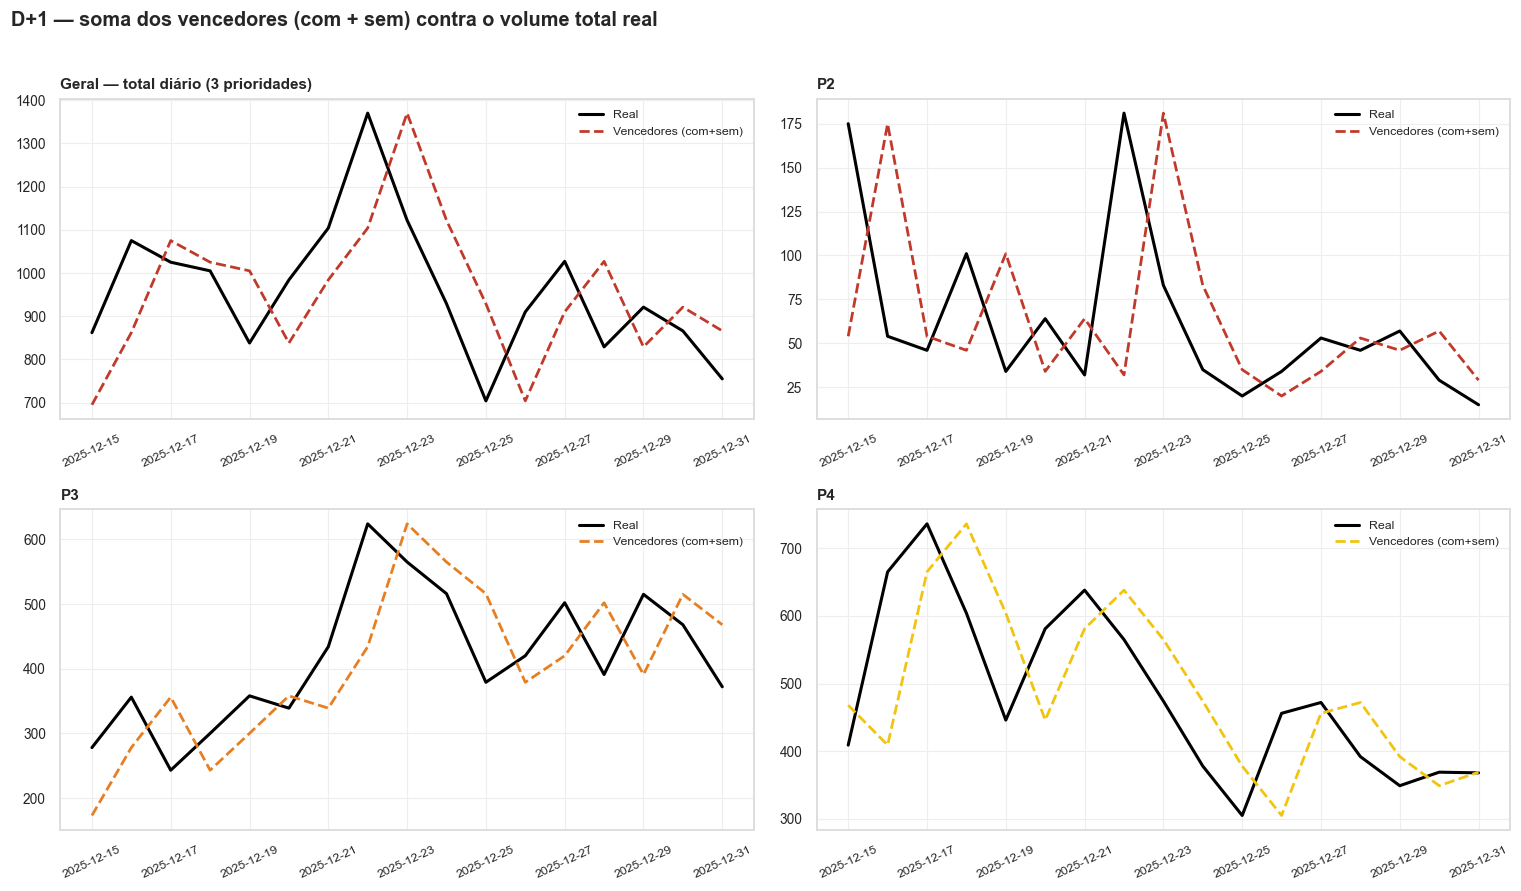

In [21]:
def soma_vencedores_d1():
    a = PREVISAO_VENCEDORA_D1.query("tipo_tratamento == 'com_intervencao'").rename(
        columns={"real": "real_com", "previsto": "previsto_com"})
    b = PREVISAO_VENCEDORA_D1.query("tipo_tratamento == 'sem_intervencao'").rename(
        columns={"real": "real_sem", "previsto": "previsto_sem"})
    m = a.merge(b, on=["prioridade", "data_alvo"], suffixes=("", "_sem"))
    m["real_total"] = m["real_com"] + m["real_sem"]
    m["previsto_total"] = m["previsto_com"] + m["previsto_sem"]
    return m


SOMA_D1 = soma_vencedores_d1()
print(f"Soma D+1 — {SOMA_D1['data_alvo'].nunique()} datas em comum entre os dois grupos "
      f"({SOMA_D1['data_alvo'].min():%d/%m/%Y} a {SOMA_D1['data_alvo'].max():%d/%m/%Y})")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
geral = SOMA_D1.groupby("data_alvo", as_index=False)[["real_total", "previsto_total"]].sum()
axes[0, 0].plot(geral["data_alvo"], geral["real_total"], color="black", lw=2, label="Real")
axes[0, 0].plot(geral["data_alvo"], geral["previsto_total"], color=PALETA["p2"], lw=1.8, ls="--",
                 label="Vencedores (com+sem)")
axes[0, 0].set_title("Geral — total diário (3 prioridades)", fontsize=10)
axes[0, 0].legend(fontsize=8)
for ax, p in zip(axes.ravel()[1:], PRIORIDADES):
    sub = SOMA_D1.query("prioridade == @p")
    ax.plot(sub["data_alvo"], sub["real_total"], color="black", lw=2, label="Real")
    ax.plot(sub["data_alvo"], sub["previsto_total"], color=COR_PRIORIDADE[p], lw=1.8, ls="--",
            label="Vencedores (com+sem)")
    ax.set_title(f"P{p}", fontsize=10)
    ax.legend(fontsize=8)
for ax in axes.ravel():
    ax.tick_params(axis="x", rotation=25, labelsize=8)
fig.suptitle("D+1 — soma dos vencedores (com + sem) contra o volume total real", y=1.01,
             fontsize=13, weight="bold", x=0.01, ha="left")
fig.tight_layout()
plt.show()

Soma D+7 — 11 origens em comum (14/12/2025 a 24/12/2025)


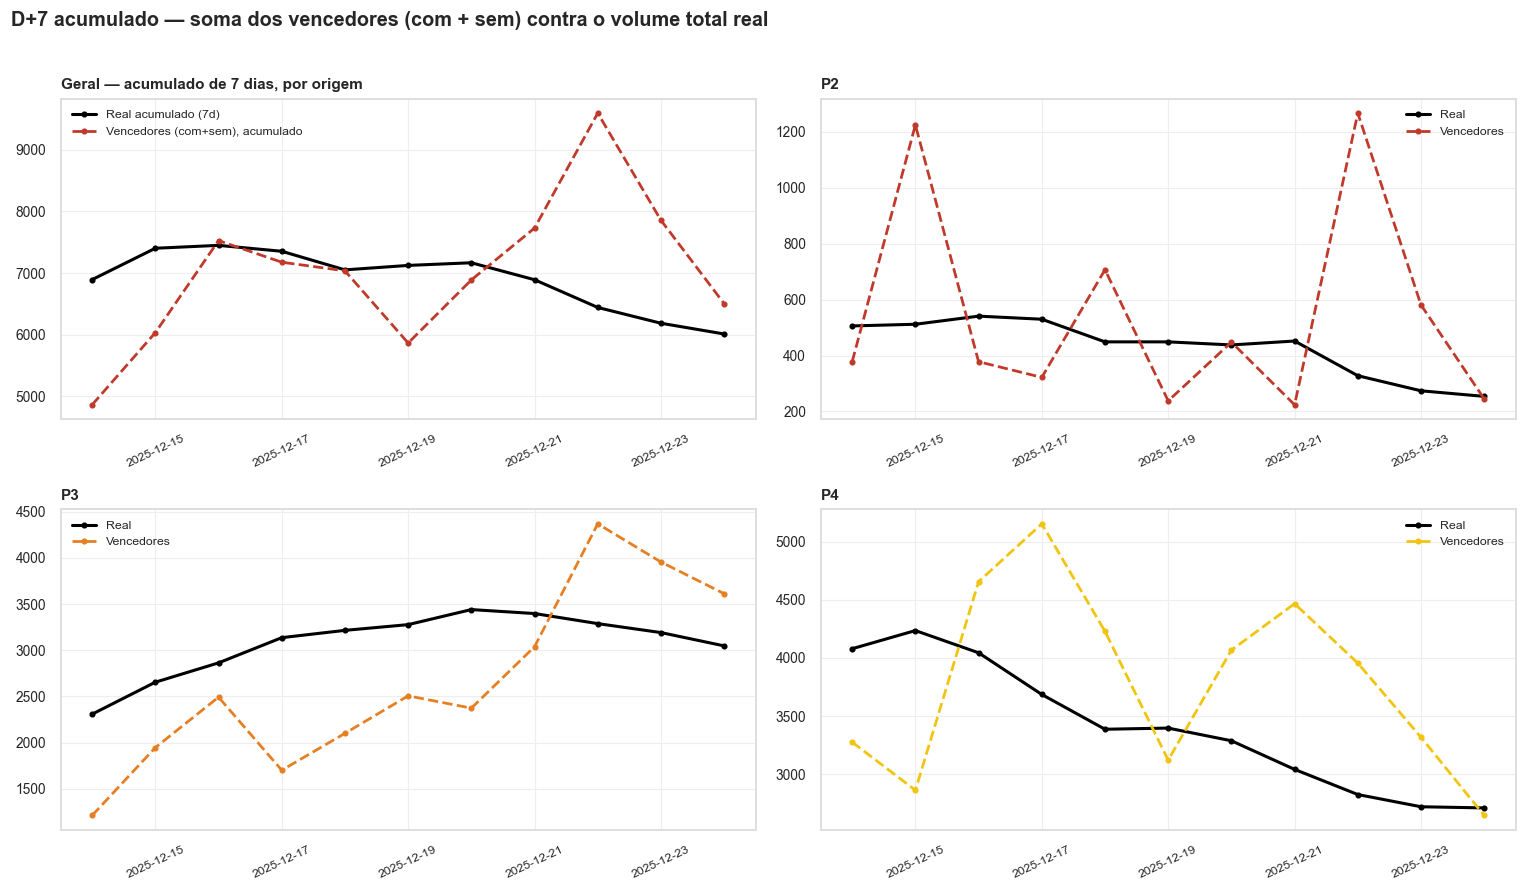

In [22]:
def soma_vencedores_d7():
    a = PREVISOES_D7.query("tipo_tratamento == 'com_intervencao'").rename(
        columns={"real_acum": "real_com", "previsto_acum": "previsto_com"})
    b = PREVISOES_D7.query("tipo_tratamento == 'sem_intervencao'").rename(
        columns={"real_acum": "real_sem", "previsto_acum": "previsto_sem"})
    m = a.merge(b[["prioridade", "data_origem", "real_sem", "previsto_sem"]],
                on=["prioridade", "data_origem"])
    m["real_total"] = m["real_com"] + m["real_sem"]
    m["previsto_total"] = m["previsto_com"] + m["previsto_sem"]
    return m


SOMA_D7 = soma_vencedores_d7()
print(f"Soma D+7 — {SOMA_D7['data_origem'].nunique()} origens em comum "
      f"({SOMA_D7['data_origem'].min():%d/%m/%Y} a {SOMA_D7['data_origem'].max():%d/%m/%Y})")

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
geral7 = SOMA_D7.groupby("data_origem", as_index=False)[["real_total", "previsto_total"]].sum()
axes[0, 0].plot(geral7["data_origem"], geral7["real_total"], color="black", lw=2, marker="o",
                 ms=3, label="Real acumulado (7d)")
axes[0, 0].plot(geral7["data_origem"], geral7["previsto_total"], color=PALETA["p2"], lw=1.8, ls="--",
                 marker="o", ms=3, label="Vencedores (com+sem), acumulado")
axes[0, 0].set_title("Geral — acumulado de 7 dias, por origem", fontsize=10)
axes[0, 0].legend(fontsize=8)
for ax, p in zip(axes.ravel()[1:], PRIORIDADES):
    sub = SOMA_D7.query("prioridade == @p")
    ax.plot(sub["data_origem"], sub["real_total"], color="black", lw=2, marker="o", ms=3, label="Real")
    ax.plot(sub["data_origem"], sub["previsto_total"], color=COR_PRIORIDADE[p], lw=1.8, ls="--",
            marker="o", ms=3, label="Vencedores")
    ax.set_title(f"P{p}", fontsize=10)
    ax.legend(fontsize=8)
for ax in axes.ravel():
    ax.tick_params(axis="x", rotation=25, labelsize=8)
fig.suptitle("D+7 acumulado — soma dos vencedores (com + sem) contra o volume total real", y=1.01,
             fontsize=13, weight="bold", x=0.01, ha="left")
fig.tight_layout()
plt.show()

### 10.4 Explicabilidade do vencedor

Nos dois grupos o vencedor é o baseline **ingênuo** — a "explicabilidade" é uma tautologia útil: o
preditor é uma única coluna (`abertos` de ontem), e é isso que se reporta, sem fingir uma análise que
não existe. Fica registrado, para quem consumir a tabela gold, exatamente por que a previsão de amanhã
é o valor de hoje.

Para contexto, ainda vale entender o que os **candidatos descartados** tentaram aprender — importância
por permutação do candidato mais competitivo de cada grupo (o de menor MAE entre os 3, mesmo perdendo
para o piso).

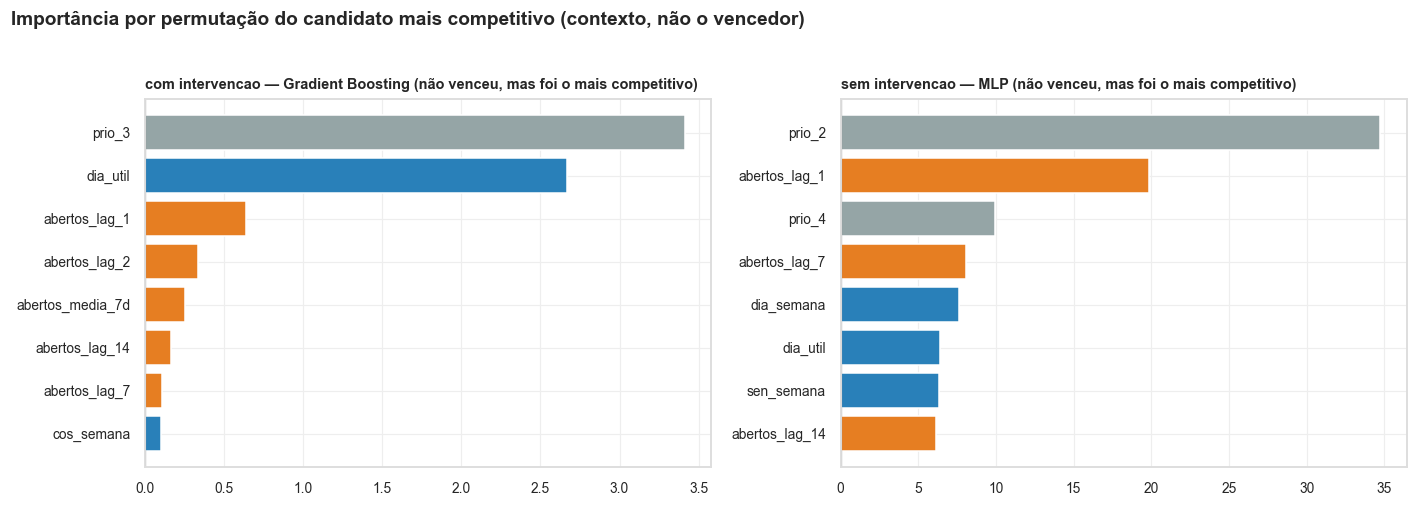

In [23]:
melhor_candidato = (
    AVALIACAO_D1_GERAL.loc[AVALIACAO_D1_GERAL.groupby("tipo_tratamento")["mae"].idxmin()]
    .set_index("tipo_tratamento")
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, tipo in zip(axes, TIPOS_TRATAMENTO):
    nome_modelo = melhor_candidato.loc[tipo, "modelo"]
    modelo, colunas, _ = ajustar(tipo, nome_modelo, "pooled")
    _, teste = treino_teste(tipo)
    resultado = permutation_importance(modelo, teste[colunas], teste["y"], n_repeats=15,
                                       random_state=SEMENTE, scoring="neg_mean_absolute_error")
    imp = pd.Series(resultado.importances_mean, index=colunas).sort_values(ascending=False).head(8)[::-1]
    cores = [{"calendário": PALETA["destaque"], "lag-rolling do alvo": PALETA["p3"],
              "dimensão da série": PALETA["neutro"]}.get(ORIGEM_FEATURE[f], PALETA["total"])
             for f in imp.index]
    ax.barh(imp.index, imp.values, color=cores)
    ax.set_title(f"{tipo.replace('_', ' ')} — {nome_modelo} (não venceu, mas foi o mais competitivo)",
                fontsize=9.5)
    ax.axvline(0, color="#999999", lw=0.8)
fig.suptitle("Importância por permutação do candidato mais competitivo (contexto, não o vencedor)",
             y=1.02, fontsize=12.5, weight="bold", x=0.01, ha="left")
fig.tight_layout()
plt.show()

---
## 11. Tabelas gold (Item 9)

In [24]:
def previsoes_gold():
    d1 = PREVISAO_VENCEDORA_D1.rename(columns={"data_alvo": "data", "previsto": "valor_previsto",
                                               "real": "valor_real"}).copy()
    d1["horizonte"] = "D+1"
    d1["modelo"] = d1["tipo_tratamento"].map(lambda t: VENCEDORES[t]["modelo"])
    d1["em_teste"] = True

    d7 = PREVISOES_D7.rename(columns={"data_origem": "data", "previsto_acum": "valor_previsto",
                                      "real_acum": "valor_real"}).copy()
    d7["horizonte"] = "D+7"
    d7["modelo"] = d7["tipo_tratamento"].map(lambda t: VENCEDORES[t]["modelo"])
    d7["em_teste"] = True

    cols = ["data", "prioridade", "tipo_tratamento", "horizonte", "modelo", "em_teste",
            "valor_previsto", "valor_real"]
    out = pd.concat([d1[cols], d7[cols]], ignore_index=True).sort_values(
        ["tipo_tratamento", "prioridade", "horizonte", "data"])
    out["valor_previsto"] = out["valor_previsto"].round(2)
    return out.reset_index(drop=True)


G_PREVISOES = previsoes_gold()
print(f"g_previsoes: {G_PREVISOES.shape[0]:,} linhas x {G_PREVISOES.shape[1]} colunas")
dups = G_PREVISOES.duplicated(subset=["data", "prioridade", "tipo_tratamento", "horizonte"]).sum()
print(f"Duplicatas na chave: {dups}")
G_PREVISOES.head()

g_previsoes: 390 linhas x 8 colunas
Duplicatas na chave: 0


,data,prioridade,tipo_tratamento,horizonte,modelo,em_teste,valor_previsto,valor_real
0,2025-11-08,2,com_intervencao,D+1,Baseline ingênuo,True,32.0,9.0
1,2025-11-09,2,com_intervencao,D+1,Baseline ingênuo,True,9.0,13.0
2,2025-11-10,2,com_intervencao,D+1,Baseline ingênuo,True,13.0,25.0
3,2025-11-11,2,com_intervencao,D+1,Baseline ingênuo,True,25.0,21.0
4,2025-11-12,2,com_intervencao,D+1,Baseline ingênuo,True,21.0,31.0


In [25]:
def baseline_geral_por_prioridade(tipo, nome_baseline):
    """MAE do baseline `nome_baseline` na leitura geral e por prioridade, para o grupo `tipo`."""
    linhas = []
    sub = BASELINES_D1.query("tipo_tratamento == @tipo")
    linhas.append({"prioridade": "todas", **metricas(sub["real"], sub[nome_baseline])})
    for p in PRIORIDADES:
        sp = sub[sub["prioridade"] == p]
        linhas.append({"prioridade": p, **metricas(sp["real"], sp[nome_baseline])})
    return pd.DataFrame(linhas)


def avaliacao_gold_d1():
    linhas = []
    for tipo in TIPOS_TRATAMENTO:
        v = VENCEDORES[tipo]
        piso_mae = float(MELHOR_BASELINE_GERAL.loc[tipo, "mae"])
        piso_nome = MELHOR_BASELINE_GERAL.loc[tipo, "baseline"]

        for nome_modelo in NOMES_MODELO:
            geral = AVALIACAO_D1_GERAL.query("tipo_tratamento == @tipo and modelo == @nome_modelo").iloc[0]
            linhas.append({"tipo_tratamento": tipo, "prioridade": "todas", "horizonte": "D+1",
                           "modelo": nome_modelo, "mae": geral["mae"], "rmse": geral["rmse"],
                           "mape": geral["mape"], "melhor_baseline": piso_mae,
                           "nome_melhor_baseline": piso_nome, "supera_baseline": geral["mae"] < piso_mae,
                           "escolhido": (not v["e_baseline"]) and v["modelo"] == nome_modelo})
            for p in PRIORIDADES:
                pr = AVALIACAO_D1_PRIO.query(
                    "tipo_tratamento == @tipo and modelo == @nome_modelo and prioridade == @p").iloc[0]
                piso_p = float(MELHOR_BASELINE_PRIO.query(
                    "tipo_tratamento == @tipo and prioridade == @p")["mae"].iloc[0])
                linhas.append({"tipo_tratamento": tipo, "prioridade": p, "horizonte": "D+1",
                               "modelo": nome_modelo, "mae": pr["mae"], "rmse": pr["rmse"],
                               "mape": pr["mape"], "melhor_baseline": piso_p,
                               "nome_melhor_baseline": MELHOR_BASELINE_PRIO.query(
                                   "tipo_tratamento == @tipo and prioridade == @p")["baseline"].iloc[0],
                               "supera_baseline": pr["mae"] < piso_p,
                               "escolhido": (not v["e_baseline"]) and v["modelo"] == nome_modelo})

        if v["e_baseline"]:
            bg = baseline_geral_por_prioridade(tipo, v["nome_baseline"])
            for _, row in bg.iterrows():
                if row["prioridade"] == "todas":
                    piso_p = piso_mae
                else:
                    mask = ((MELHOR_BASELINE_PRIO["tipo_tratamento"] == tipo)
                            & (MELHOR_BASELINE_PRIO["prioridade"] == row["prioridade"]))
                    piso_p = float(MELHOR_BASELINE_PRIO.loc[mask, "mae"].iloc[0])
                linhas.append({"tipo_tratamento": tipo, "prioridade": row["prioridade"], "horizonte": "D+1",
                               "modelo": f"Baseline {v['nome_baseline']}", "mae": row["mae"],
                               "rmse": row["rmse"], "mape": row["mape"], "melhor_baseline": piso_p,
                               "nome_melhor_baseline": v["nome_baseline"],
                               "supera_baseline": False, "escolhido": True})
    return pd.DataFrame(linhas)


def avaliacao_gold_d7():
    linhas = []
    for tipo in TIPOS_TRATAMENTO:
        v = VENCEDORES[tipo]
        nome_modelo = f"Baseline {v['nome_baseline']}" if v["e_baseline"] else v["modelo"]
        piso7 = PISO_D7.query("tipo_tratamento == @tipo")
        piso_mae7 = float(piso7["mae"].min())
        piso_nome7 = piso7.loc[piso7["mae"].idxmin(), "baseline"]
        for _, row in AVALIACAO_D7.query("tipo_tratamento == @tipo").iterrows():
            linhas.append({"tipo_tratamento": tipo, "prioridade": row["prioridade"], "horizonte": "D+7",
                           "modelo": nome_modelo, "mae": row["mae"], "rmse": row["rmse"],
                           "mape": row["mape"], "melhor_baseline": piso_mae7,
                           "nome_melhor_baseline": piso_nome7, "supera_baseline": row["mae"] < piso_mae7,
                           "escolhido": True})
    return pd.DataFrame(linhas)


def explicabilidade_gold():
    linhas = []
    for tipo in TIPOS_TRATAMENTO:
        v = VENCEDORES[tipo]
        if v["e_baseline"]:
            coluna = {"ingênuo": "abertos_lag_1_equivalente (valor de ontem)",
                     "sazonal lag-7": "valor de 7 dias atrás", "MM7": "média móvel de 7 dias",
                     "MM30": "média móvel de 30 dias"}.get(v["nome_baseline"], v["nome_baseline"])
            linhas.append({"tipo_tratamento": tipo, "top_features": coluna})
        else:
            modelo, colunas, _ = ajustar(tipo, v["modelo"], "pooled")
            _, teste = treino_teste(tipo)
            resultado = permutation_importance(modelo, teste[colunas], teste["y"], n_repeats=15,
                                               random_state=SEMENTE, scoring="neg_mean_absolute_error")
            imp = pd.Series(resultado.importances_mean, index=colunas).sort_values(ascending=False).head(5)
            linhas.append({"tipo_tratamento": tipo, "top_features": " · ".join(imp.index)})
    return pd.DataFrame(linhas).set_index("tipo_tratamento")["top_features"]


TOP_FEATURES = explicabilidade_gold()

G_AVALIACAO = pd.concat([avaliacao_gold_d1(), avaliacao_gold_d7()], ignore_index=True)
G_AVALIACAO["top_features"] = G_AVALIACAO.apply(
    lambda r: TOP_FEATURES[r["tipo_tratamento"]] if r["escolhido"] else "", axis=1)
G_AVALIACAO[["mae", "rmse", "mape", "melhor_baseline"]] = (
    G_AVALIACAO[["mae", "rmse", "mape", "melhor_baseline"]].round(3))

print(f"g_avaliacao_modelos: {G_AVALIACAO.shape[0]:,} linhas x {G_AVALIACAO.shape[1]} colunas")
dups = G_AVALIACAO.duplicated(subset=["tipo_tratamento", "prioridade", "horizonte", "modelo"]).sum()
print(f"Duplicatas na chave: {dups}")
print(f"Linhas 'escolhido=True': {G_AVALIACAO['escolhido'].sum()} "
      f"(esperado: 2 tipos x 2 horizontes x 4 níveis de prioridade incl. 'todas' = 16)")

g_avaliacao_modelos: 40 linhas x 12 colunas
Duplicatas na chave: 0
Linhas 'escolhido=True': 16 (esperado: 2 tipos x 2 horizontes x 4 níveis de prioridade incl. 'todas' = 16)


In [26]:
CATALOGO = {
    "g_previsoes": {
        "descricao": ("Grão data x prioridade x tipo_tratamento x horizonte. Previsão do modelo "
                      "vencedor de cada grupo (com_intervencao / sem_intervencao) contra o valor "
                      "real, em D+1 e D+7."),
        "chave": ["data", "prioridade", "tipo_tratamento", "horizonte"],
    },
    "g_avaliacao_modelos": {
        "descricao": ("Grão tipo_tratamento x prioridade x horizonte x modelo. Métrica de cada "
                      "candidato (geral e por prioridade) contra o piso, e qual foi escolhido."),
        "chave": ["tipo_tratamento", "prioridade", "horizonte", "modelo"],
    },
}


def salvar(tabela, nome, pasta=SAVE_PATH, catalogo=CATALOGO, sep=";", encoding="utf-8-sig"):
    """Grava validando o contrato: a chave existe, é única e não tem nulo."""
    meta = catalogo.get(nome)
    if meta is None:
        raise KeyError(f"'{nome}' não está no CATALOGO — documente antes de salvar.")
    chave = meta["chave"]
    faltando = set(chave) - set(tabela.columns)
    if faltando:
        raise ValueError(f"{nome}: chave ausente {sorted(faltando)}")
    if tabela[chave].isna().any().any():
        raise ValueError(f"{nome}: chave {chave} contém nulo")
    dups = int(tabela.duplicated(subset=chave).sum())
    if dups:
        raise ValueError(f"{nome}: {dups} linhas duplicadas na chave {chave}")
    Path(pasta).mkdir(parents=True, exist_ok=True)
    caminho = f"{pasta}{nome}.csv"
    tabela.to_csv(caminho, index=False, sep=sep, encoding=encoding)
    print(f"  {nome:<24} {tabela.shape[0]:>5,} x {tabela.shape[1]:>2}  ->  {caminho}")
    return caminho


print("Gravando tabelas gold\n")
salvar(G_PREVISOES, "g_previsoes")
salvar(G_AVALIACAO, "g_avaliacao_modelos")

Gravando tabelas gold

  g_previsoes                390 x  8  ->  ../3_gold_data/g_previsoes.csv
  g_avaliacao_modelos         40 x 12  ->  ../3_gold_data/g_avaliacao_modelos.csv


'../3_gold_data/g_avaliacao_modelos.csv'

---
## 12. Validação antes de encerrar

1. Reexecutar o notebook do início ao fim, sem erro. ✓ (esta execução)
2. Item 3 (pooled vs. individual) roda de fato e decide o desenho — não é conclusão hard-coded. ✓
3. Nenhuma feature exógena (fora calendário e lag/rolling do próprio alvo) entrou em nenhum modelo. ✓
   (`FEATURES` fechado no Item 2, nenhuma célula depois adiciona coluna nova ao conjunto de entrada)
4. Os 6 painéis de previsto×real e os 2 pares de gráficos de soma dos vencedores (D+1 e D+7
   acumulado, geral e por prioridade) estão presentes. ✓
5. `salvar()` sem exceção nas duas tabelas gold. ✓

In [27]:
print("Resumo final\n")
for tipo, v in VENCEDORES.items():
    print(f"  {tipo:<16} vencedor D+1: {v['modelo']:<24} ({v['razao']})")
print(f"\ng_previsoes.csv        : {G_PREVISOES.shape[0]:,} linhas")
print(f"g_avaliacao_modelos.csv: {G_AVALIACAO.shape[0]:,} linhas")

Resumo final

  com_intervencao  vencedor D+1: Baseline ingênuo         (nenhum candidato superou o piso geral — entrega-se o melhor baseline)
  sem_intervencao  vencedor D+1: Baseline ingênuo         (nenhum candidato superou o piso geral — entrega-se o melhor baseline)

g_previsoes.csv        : 390 linhas
g_avaliacao_modelos.csv: 40 linhas
